# Internship Program Analysis

## Problem Statement

Internship programs involve multiple departments, mentors, and participants, making it challenging to monitor enrollment, track intern progress, and evaluate overall program performance. Analyzing internship data helps identify completion trends, dropout patterns, department participation, internship duration, and mentor engagement. These insights support data-driven decision-making and help improve future internship programs.

## Project Objectives

The main objectives of this analysis are to:

- Analyze internship enrollment trends.
- Calculate internship completion and dropout rates.
- Examine department-wise participation.
- Analyze internship duration and completion progress.
- Evaluate mentor interactions.
- Generate meaningful visualizations and insights.

## Dataset Information

This dataset contains internship records for the year **2025**. It includes information about interns, educational background, departments, internship tracks, mentors, enrollment dates, internship progress, task submissions, mentor interactions, and completion status.

The dataset is used to perform exploratory data analysis (EDA) to identify patterns and generate insights related to internship program performance.

### Dataset Summary

| Attribute | Details |
|-----------|---------|
| **Dataset Name** | Internship Program Dataset |
| **Time Period** | 2025 |
| **File Format** | CSV (.csv) |
| **Number of Records** | 70,000 |
| **Number of Features** | 17 |
| **Data Type** | Structured Tabular Data |
| **Primary Goal** | Internship Program Analysis |

### Dataset Features

| Feature | Description |
|----------|-------------|
| **Intern_ID** | Unique identifier assigned to each intern |
| **Intern_Name** | Name of the intern |
| **Gender** | Gender of the intern |
| **Age** | Age of the intern |
| **City** | City of residence |
| **Education** | Educational qualification |
| **Institute** | Educational institute |
| **Department** | Internship department |
| **Internship_Track** | Internship specialization |
| **Mentor_ID** | Unique identifier assigned to each mentor |
| **Mentor_Name** | Name of the assigned mentor |
| **Enrollment_Date** | Internship enrollment date |
| **Internship_Duration_Weeks** | Total internship duration |
| **Weeks_Completed** | Number of weeks completed |
| **Tasks_Submitted** | Number of submitted tasks |
| **Mentor_Interactions** | Total mentor interactions |
| **Status** | Internship completion status |

## Import Required Libraries

This project uses Python libraries for data manipulation, analysis, and visualization. Pandas and NumPy are used for handling and processing data, while Matplotlib and Seaborn are used to create clear and informative visualizations that help identify patterns and trends within the dataset.

In [2]:
# Import Pandas for data manipulation and analysis
import pandas as pd

# Import NumPy for numerical computations
import numpy as np

# Import Matplotlib for creating visualizations
import matplotlib.pyplot as plt

# Import Seaborn for statistical data visualization
import seaborn as sns

## Load the Dataset

In this section, the internship dataset is loaded into a Pandas DataFrame. The `Enrollment_Date` column is converted to a datetime format to enable accurate date-based analysis and visualization throughout the project.

In [3]:
# Load the dataset
internship_df = pd.read_csv("../data/raw/internship_program_2025.csv")

# Convert the Enrollment_Date column to datetime format
internship_df["Enrollment_Date"] = pd.to_datetime(internship_df["Enrollment_Date"])

## Dataset Overview

This section provides an overview of the dataset to verify its structure, understand the available features, and ensure that the data has been loaded correctly before performing further analysis.

In [4]:
# Display the first five records
internship_df.head()

,Intern_ID,Intern_Name,Gender,Age,City,Education,Institute,Department,Internship_Track,Mentor_ID,Mentor_Name,Enrollment_Date,Internship_Duration_Weeks,Weeks_Completed,Tasks_Submitted,Mentor_Interactions,Status
0,INT00001,Ahmed Shafiq,Male,21,Peshawar,BS Computer Science,COMSATS University Islamabad,App Development,Android,MEN020,Huzaifa Waheed,2025-02-14,8,4,0,8,Dropped
1,INT00002,Adeel Chishti,Male,20,Rahim Yar Khan,FSC (Pre-Engineering),Government College Faisalabad,Frontend Development,React,MEN007,Fatima Ali,2025-08-25,8,8,8,17,Completed
2,INT00003,Areeba Hussain,Female,25,Multan,MS Computer Science,Government College University (GCU),Frontend Development,React,MEN007,Fatima Ali,2025-04-09,8,8,8,19,Completed
3,INT00004,Rafay Chaudhry,Male,24,Gwadar,BS Data Science,Riphah International University,Backend Development,PHP,MEN001,Ahmed Khan,2025-06-25,8,8,6,16,Completed
4,INT00005,Rafay Hashmi,Male,24,Gujranwala,BS Software Engineering,Riphah International University,Frontend Development,HTML CSS JS,MEN006,Ayesha Noor,2025-04-30,8,8,6,20,Completed


In [5]:
# Display dataset information
internship_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 70000 entries, 0 to 69999
Data columns (total 17 columns):
 #   Column                     Non-Null Count  Dtype         
---  ------                     --------------  -----         
 0   Intern_ID                  70000 non-null  str           
 1   Intern_Name                70000 non-null  str           
 2   Gender                     70000 non-null  str           
 3   Age                        70000 non-null  int64         
 4   City                       70000 non-null  str           
 5   Education                  70000 non-null  str           
 6   Institute                  70000 non-null  str           
 7   Department                 70000 non-null  str           
 8   Internship_Track           70000 non-null  str           
 9   Mentor_ID                  70000 non-null  str           
 10  Mentor_Name                70000 non-null  str           
 11  Enrollment_Date            70000 non-null  datetime64[us]
 12  Internship_Dura

### Observation

- The dataset contains **70,000 records** and **17 features**.
- All columns contain complete records with no missing values.
- The dataset includes categorical, numerical, and datetime features.
- The `Enrollment_Date` column has been successfully converted to the datetime data type.
- The dataset is ready for data quality assessment and exploratory data analysis.

## Data Validation

Before starting the exploratory data analysis, the dataset is validated to ensure that it follows the expected business rules. This includes checking categorical values, identifying duplicate records, and verifying that numerical values fall within valid ranges.

In [6]:
# Check for duplicate records
print("Duplicated Records: ",internship_df.duplicated().sum())

Duplicated Records:  0


In [7]:
# Display unique values in important categorical columns
categorical_columns = [
    "Gender",
    "City",
    "Education",
    "Institute",
    "Department",
    "Internship_Track",
    "Status"
]

for column in categorical_columns:
    print("=" * 100)
    print(f"{column} ({internship_df[column].nunique()} Unique Values)")
    print("-" * 100)

    values = sorted(internship_df[column].unique())

    for value in values:
        print(f"• {value}")

    print()



Gender (2 Unique Values)
----------------------------------------------------------------------------------------------------
• Female
• Male

City (40 Unique Values)
----------------------------------------------------------------------------------------------------
• Abbottabad
• Bahawalpur
• Bannu
• Chiniot
• Dera Ghazi Khan
• Faisalabad
• Gujranwala
• Gujrat
• Gwadar
• Hyderabad
• Islamabad
• Jacobabad
• Jhang
• Karachi
• Kasur
• Khushab
• Kohat
• Lahore
• Larkana
• Mardan
• Mingora
• Mirpur Khas
• Multan
• Muzaffarabad
• Nawabshah
• Nowshera
• Okara
• Pakpattan
• Peshawar
• Quetta
• Rahim Yar Khan
• Rawalpindi
• Sahiwal
• Sargodha
• Sheikhupura
• Sialkot
• Sukkur
• Turbat
• Vehari
• Wah Cantt

Education (19 Unique Values)
----------------------------------------------------------------------------------------------------
• BBA
• BS Artificial Intelligence
• BS Computer Engineering
• BS Computer Science
• BS Cyber Security
• BS Data Analytics
• BS Data Science
• BS Information Tech

### Validate Business Rules

The following checks verify that the numerical values satisfy the expected business rules defined for the internship program.

In [8]:
# Validate internship duration

internship_df["Internship_Duration_Weeks"].value_counts()

Internship_Duration_Weeks
8    70000
Name: count, dtype: int64

In [9]:
# Validate completed weeks

print(f"Minimum Weeks Completed : {internship_df['Weeks_Completed'].min()}")

print(f"Maximum Weeks Completed : {internship_df['Weeks_Completed'].max()}")

Minimum Weeks Completed : 1
Maximum Weeks Completed : 8


In [10]:
# Validate submitted tasks

print(f"Minimum Tasks Submitted : {internship_df['Tasks_Submitted'].min()}")

print(f"Maximum Tasks Submitted : {internship_df['Tasks_Submitted'].max()}")

Minimum Tasks Submitted : 0
Maximum Tasks Submitted : 8


In [11]:
# Validate age values

print(f"Minimum Age : {internship_df['Age'].min()}")

print(f"Maximum Age : {internship_df['Age'].max()}")

Minimum Age : 17
Maximum Age : 32


In [12]:
# Validate mentor interactions

print(f"Minimum Mentor Interactions : {internship_df['Mentor_Interactions'].min()}")

print(f"Maximum Mentor Interactions : {internship_df['Mentor_Interactions'].max()}")

Minimum Mentor Interactions : 2
Maximum Mentor Interactions : 20


### Observation

- No duplicate records were found in the dataset.
- All categorical features contain valid and consistent categories.
- The numerical values satisfy the defined business rules.
- No invalid or unexpected values were identified during the validation process.
- The dataset is ready for exploratory data analysis.

## Exploratory Data Analysis (EDA)

Exploratory Data Analysis (EDA) is performed to understand the characteristics of the internship dataset and identify meaningful patterns through statistical analysis and data visualization. The analysis focuses on enrollment trends, completion status, department participation, internship progress, and mentor engagement.

### Monthly Internship Enrollment Trend

This analysis examines the monthly distribution of internship enrollments throughout 2025. Understanding enrollment trends helps identify peak registration periods and supports effective planning for recruitment, onboarding, mentor allocation, and training resources.

In [14]:
# Monthly Internship Enrollment Analysis

# Extract the enrollment month from the enrollment date
internship_df["Enrollment_Month"] = (
    internship_df["Enrollment_Date"].dt.month_name()
)

# Define the chronological order of enrollment months
month_order = [
    "January", "February", "March", "April",
    "May", "June", "July", "August",
    "September", "October"
]

# Calculate the number of interns enrolled each month
monthly_enrollment = (
    internship_df["Enrollment_Month"]
    .value_counts()
    .reindex(month_order)
)

# Display the monthly enrollment summary
monthly_enrollment

Enrollment_Month
January       3611
February      4926
March         6882
April        10576
May          12550
June         11197
July          7665
August        5478
September     4314
October       2801
Name: count, dtype: int64

#### Monthly Internship Enrollment Visualization

The following visualization presents the monthly distribution of internship enrollments throughout 2025. It highlights seasonal enrollment patterns and helps identify periods of high and low internship registrations.

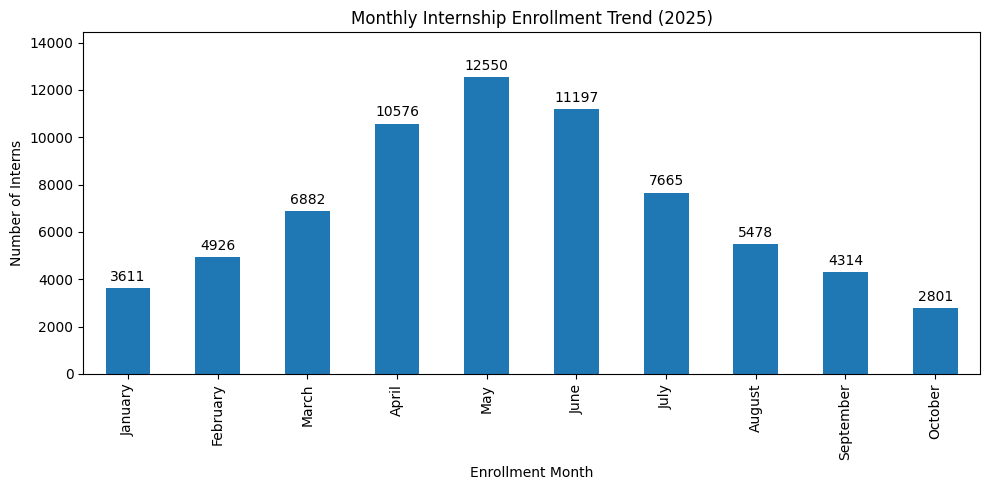

In [49]:
# Monthly Internship Enrollment Visualization

# Create the figure
plt.figure(figsize=(10, 5))

# Create the bar chart
ax = monthly_enrollment.plot(
    kind="bar"
)

# Add chart title
plt.title("Monthly Internship Enrollment Trend (2025)")

# Add axis labels
plt.xlabel("Enrollment Month")
plt.ylabel("Number of Interns")

plt.ylim(0, monthly_enrollment.max() * 1.15)

# Rotate x-axis labels
plt.xticks(rotation=90)

# Display data labels
ax.bar_label(
    ax.containers[0],
    padding=3
)

# Adjust layout
plt.tight_layout()

# Save the figure
# plt.savefig(
#     "../outputs/figures/01_monthly_enrollment_trend.png",
#     dpi=300,
#     bbox_inches="tight"
# )

# Display the chart
plt.show()

#### Observation

The monthly internship enrollment trend shows a clear seasonal pattern throughout 2025. Enrollment increased steadily from **3,611 interns in January** to a peak of **12,550 interns in May**, followed by a gradual decline through **October (2,801 interns)**. This indicates that internship registrations were concentrated during the middle months of the year rather than being evenly distributed.

#### Business Insight

The concentration of internship enrollments between **April and June** indicates the organization's peak recruitment period. To efficiently manage the increased intern intake, additional onboarding sessions, mentor availability, and training resources should be planned during these months. Conversely, the lower enrollment period from **September to October** can be utilized for program evaluation, mentor training, and preparation for the next recruitment cycle.

### Internship Completion Status Analysis

This analysis examines the overall completion status of the internship program by comparing the number of interns who successfully completed the program with those who dropped out. The findings provide insights into program completion performance and participant retention.

In [28]:
# Internship Completion Status Analysis

# Calculate the number of interns by completion status
completion_status = (
    internship_df["Status"]
    .value_counts()
)

# Display the completion status summary
completion_status

Status
Completed    59413
Dropped      10587
Name: count, dtype: int64

#### Internship Completion Status Visualization

The following visualization presents the distribution of internship completion status, highlighting the proportion of interns who successfully completed the program compared to those who dropped out.

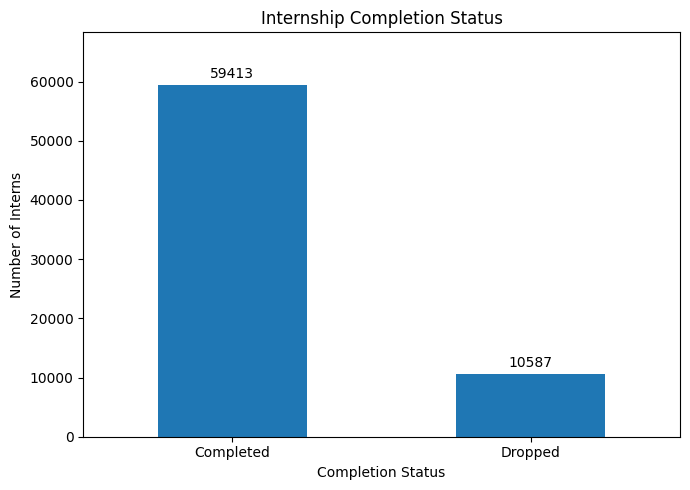

In [42]:
# Internship Completion Status Visualization

# Create the figure
plt.figure(figsize=(7, 5))

# Create the bar chart
ax = completion_status.plot(
    kind="bar"
)

# Add chart title
plt.title("Internship Completion Status")

# Add axis labels
plt.xlabel("Completion Status")
plt.ylabel("Number of Interns")

plt.ylim(0, completion_status.max() * 1.15)

# Rotate x-axis labels
plt.xticks(rotation=0)

# Display data labels
ax.bar_label(
    ax.containers[0],
    padding=3
)

# Adjust layout
plt.tight_layout()

# Save the figure
# plt.savefig(
#     "../outputs/figures/02_internship_completion_status.png",
#     dpi=300,
#     bbox_inches="tight"
# )

# Display the chart
plt.show()

#### Observation

The internship completion status indicates that the majority of interns successfully completed the program. Out of **70,000 interns**, **59,413** completed the internship, while **10,587** dropped out. This reflects a high completion rate, suggesting that most participants remained engaged throughout the internship program.

#### Business Insight

The high number of completed internships suggests that the program is effective in retaining participants and supporting them through successful completion. However, analyzing the reasons behind the **10,587 dropped** interns could help identify potential challenges such as workload, engagement, or mentorship gaps. Addressing these factors may further improve retention and overall program success.

### Monthly Internship Completion Status

This analysis examines the number of interns who completed or dropped the internship program across different enrollment months. It helps identify monthly variations in completion outcomes and provides insights into periods where intern retention was stronger or weaker.

In [40]:
month_order = [
    "January",
    "February",
    "March",
    "April",
    "May",
    "June",
    "July",
    "August",
    "September",
    "October"
]

monthly_completion = (
    internship_df
    .groupby(["Enrollment_Month", "Status"])
    .size()
    .unstack(fill_value=0)
    .reindex(month_order)
)

monthly_completion

Status,Completed,Dropped
Enrollment_Month,,
January,3083,528
February,4205,721
March,5850,1032
April,9008,1568
May,10652,1898
June,9468,1729
July,6471,1194
August,4637,841
September,3647,667


#### Monthly Internship Completion Status Visualization

This grouped bar chart illustrates the monthly distribution of completed and dropped internships based on the enrollment month. It compares the number of interns who successfully completed the internship with those who dropped out each month, making it easier to identify monthly completion patterns and evaluate intern retention throughout the internship program.

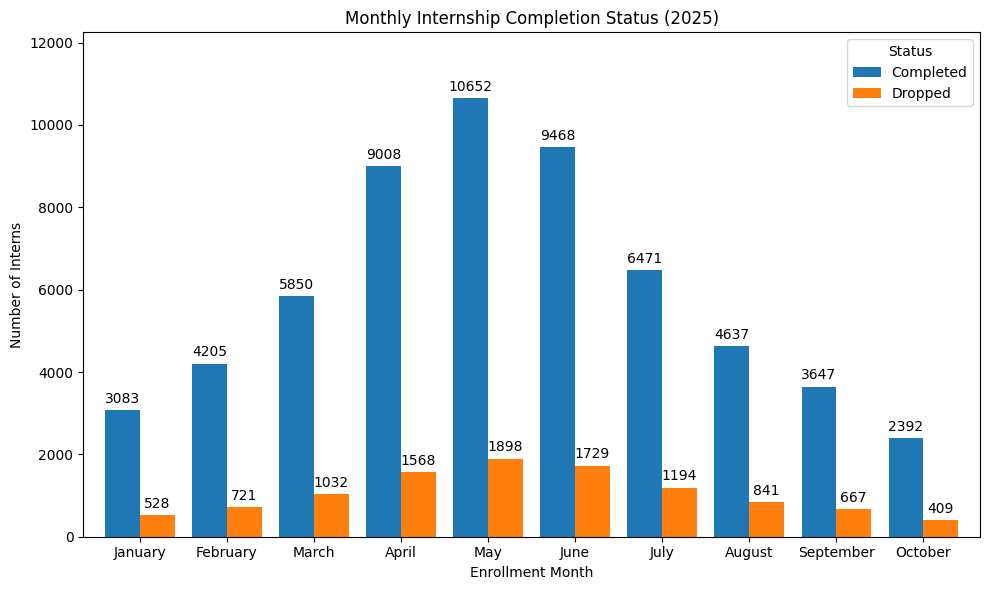

In [63]:
# Monthly Internship Completion Status Visualization



# Create the bar chart
ax = monthly_completion.plot(
    kind="bar",
    figsize=(10, 6),
    width=0.80
)

# Add chart title
plt.title("Monthly Internship Completion Status (2025)")

# Add axis labels
plt.xlabel("Enrollment Month")
plt.ylabel("Number of Interns")

plt.ylim(0, monthly_completion.max().max() * 1.15)

# Rotate x-axis labels
plt.xticks(rotation=0)

# Display data labels
for container in ax.containers:
    ax.bar_label(
        container,
        padding=3
    )

# Adjust layout
plt.tight_layout()

# Save the figure
# plt.savefig(
#     "../outputs/figures/03_monthly_internship_completion_status.png",
#     dpi=300,
#     bbox_inches="tight"
# )

# Display the chart
plt.show()

#### Observation

The monthly internship completion status shows a clear variation across enrollment months. The number of completed internships increased steadily from **3,083 in January** to a peak of **10,652 in May**, before gradually declining to **2,392 in October**. Similarly, dropped internships rose from **528 in January** to **1,898 in May** and then decreased to **409 in October**. Throughout the year, completed internships consistently remained higher than dropped internships across all enrollment months.

#### Business Insight

The monthly completion trends indicate periods of varying internship activity throughout the year. The organization should ensure sufficient mentor availability, onboarding support, and engagement initiatives during peak months, particularly from **April to June**, to effectively manage the larger number of interns. During lower-activity months, resources can be allocated to program evaluation, mentor training, and planning for future internship cycles to further strengthen intern retention and overall program performance.

### Department-wise Internship Distribution

This analysis examines the distribution of interns across different departments within the internship program. It identifies the departments that attracted the highest and lowest number of interns, providing insights into internship demand across various domains.

In [64]:
# Department-wise Internship Distribution

# Count interns in each department
department_distribution = (
    internship_df["Department"]
    .value_counts()
)

# Display summary table
department_distribution

Department
Backend Development     18238
Frontend Development    16115
Other Internships       14155
App Development         11143
Graphic Design           6879
Chatbot Development      3470
Name: count, dtype: int64

#### Department-wise Internship Distribution Visualization

This bar chart presents the number of interns enrolled in each department. It provides a clear comparison of department-wise participation, making it easier to identify the most and least popular internship departments.

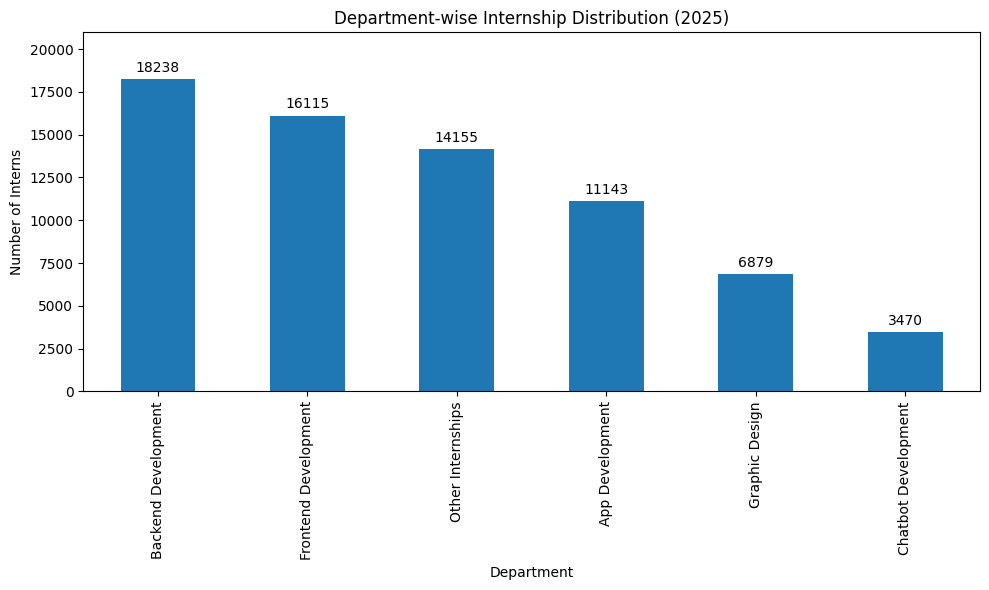

In [68]:
# Department-wise Internship Distribution Visualization

# Create the bar chart
ax = department_distribution.plot(
    kind="bar",
    figsize=(10, 6)
)

# Add chart title
plt.title("Department-wise Internship Distribution (2025)")

# Add axis labels
plt.xlabel("Department")
plt.ylabel("Number of Interns")

plt.ylim(0, department_distribution.max() * 1.15)

# Rotate x-axis labels
plt.xticks(rotation=90)

# Display data labels
for container in ax.containers:
    ax.bar_label(
        container,
        padding=3
    )

# Adjust layout
plt.tight_layout()

# Save the figure
plt.savefig(
    "../outputs/figures/04_department_wise_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

# Display the chart
plt.show()

#### Observation

The department-wise internship distribution shows noticeable variation across different departments. **Backend Development** recorded the highest number of interns (**18,238**), followed by **Frontend Development** (**16,115**) and **Other Internships** (**14,155**). **App Development** enrolled **11,143** interns, while **Graphic Design** (**6,879**) and **Chatbot Development** (**3,470**) had the lowest participation. This indicates that internship enrollment was concentrated in a few departments rather than being evenly distributed across all domains.

#### Business Insight

The higher enrollment in Backend and Frontend Development reflects stronger demand for software development roles within the internship program. To maintain program quality, the organization should allocate sufficient mentors, projects, and learning resources to these high-demand departments. At the same time, departments with lower participation, such as Graphic Design and Chatbot Development, can be promoted through targeted awareness campaigns and expanded project opportunities to encourage a more balanced distribution of interns.

### Monthly Department-wise Internship Distribution

This analysis examines the monthly distribution of interns across different departments throughout 2025. It highlights how internship participation varied by department over time and helps identify monthly enrollment patterns across different domains.

In [69]:
# Monthly Department-wise Internship Distribution

monthly_department_distribution = (
    internship_df
    .groupby(["Enrollment_Month", "Department"])
    .size()
    .unstack(fill_value=0)
    .reindex(month_order)
)

# Display summary table
monthly_department_distribution

Department,App Development,Backend Development,Chatbot Development,Frontend Development,Graphic Design,Other Internships
Enrollment_Month,,,,,,
January,577,924,173,827,350,760
February,775,1304,254,1158,453,982
March,1130,1800,330,1543,667,1412
April,1652,2714,528,2445,1090,2147
May,2043,3273,608,2889,1212,2525
June,1749,2878,556,2591,1079,2344
July,1240,1973,398,1803,736,1515
August,853,1452,289,1240,587,1057
September,701,1133,203,985,441,851


#### Monthly Department-wise Internship Distribution Visualization

This grouped bar chart illustrates the monthly distribution of interns across different departments. It compares department-wise internship enrollments for each month, making it easier to identify participation patterns and seasonal variations throughout the internship program.

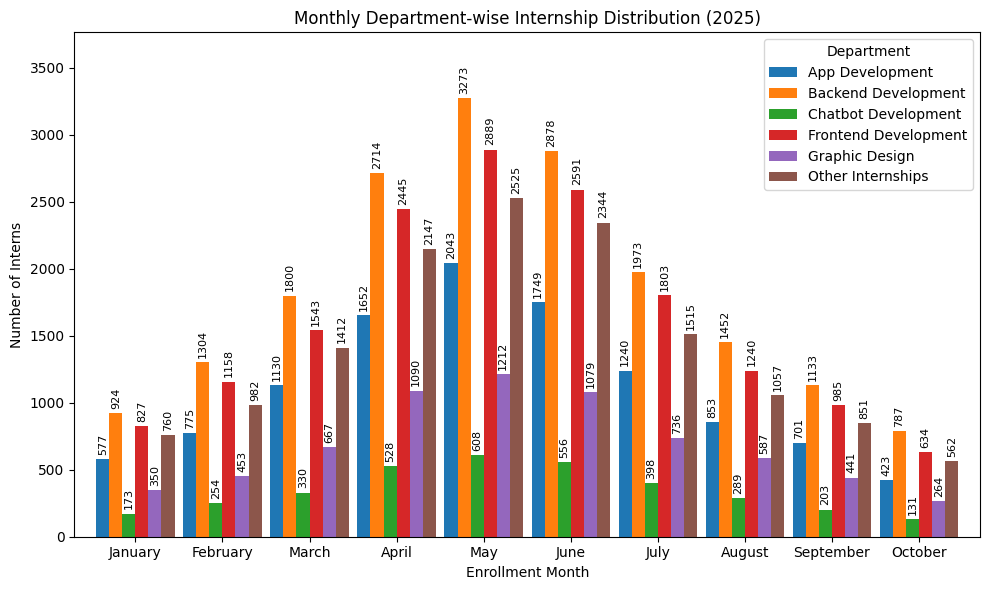

In [146]:
# Monthly Department-wise Internship Distribution Visualization

# Create the bar chart
ax = monthly_department_distribution.plot(
    kind="bar",
    figsize=(10, 6),
    width=0.90
)

# Add chart title
plt.title("Monthly Department-wise Internship Distribution (2025)")

# Add axis labels
plt.xlabel("Enrollment Month")
plt.ylabel("Number of Interns")

plt.ylim(0, monthly_department_distribution.max().max() * 1.15)

# Rotate x-axis labels
plt.xticks(rotation=0)

# Display data labels
for container in ax.containers:
    labels = ax.bar_label(
        container,
        padding=3,
        fontsize=8
    )
    for label in labels:
        label.set_rotation(90)

# Adjust layout
plt.tight_layout()

# Save the figure
# plt.savefig(
#     "../outputs/figures/05_monthly_department_wise_distribution.png",
#     dpi=300,
#     bbox_inches="tight"
# )

# Display the chart
plt.show()

#### Observation

The monthly department-wise internship distribution shows that internship enrollments increased steadily from **January** and reached their highest level in **May**, followed by a gradual decline through **October**. Across all enrollment months, **Backend Development** consistently recorded the highest number of interns, followed by **Frontend Development** and **Other Internships**. In contrast, **Graphic Design** and **App Development** maintained comparatively lower enrollment counts throughout the internship period.

#### Business Insight

The consistently higher enrollments in **Backend Development** and **Frontend Development** indicate strong and sustained demand for software development-related internship tracks. During peak enrollment months, particularly **April** and **May**, the organization should allocate additional mentors, technical resources, and project opportunities to accommodate increased participation. Furthermore, targeted promotional initiatives and specialized internship projects for departments with lower enrollments, such as **Graphic Design** and **App Development**, may help improve participation and create a more balanced internship portfolio.

### Internship Track Distribution

This analysis examines the distribution of interns across different internship tracks. It identifies the most and least popular tracks, providing insights into intern preferences and the organization's demand across various career pathways.

In [116]:
# Internship Track Distribution

track_distribution = (
    internship_df["Internship_Track"]
    .value_counts()
    .rename("Number of Interns")
)

# Display summary table
track_distribution

Internship_Track
PHP                 6364
Node.js             4588
React               4489
Flutter             4242
MERN Stack          3618
HTML CSS JS         3583
Data Science        3410
React Native        3396
WordPress           2863
Data Analytics      2844
Photoshop           2611
Android             2437
Next.js             2280
Cloud Computing     2005
Illustrator         1968
MEAN Stack          1840
Web 3.0             1828
Figma               1763
Machine Learning    1734
Cyber Security      1663
Social Media        1396
Generative AI       1338
Angular             1281
Video Editing       1103
Swift               1068
Django               970
RASA                 740
Dialogflow           734
.NET Core            649
Autodesk Maya        537
Alexa Skill          347
Salesforce CRM       311
Name: Number of Interns, dtype: int64

#### Internship Track Distribution Visualization

This bar chart illustrates the number of interns enrolled in each internship track. It provides a comparison of track-wise participation, highlighting the most and least preferred internship tracks within the program.

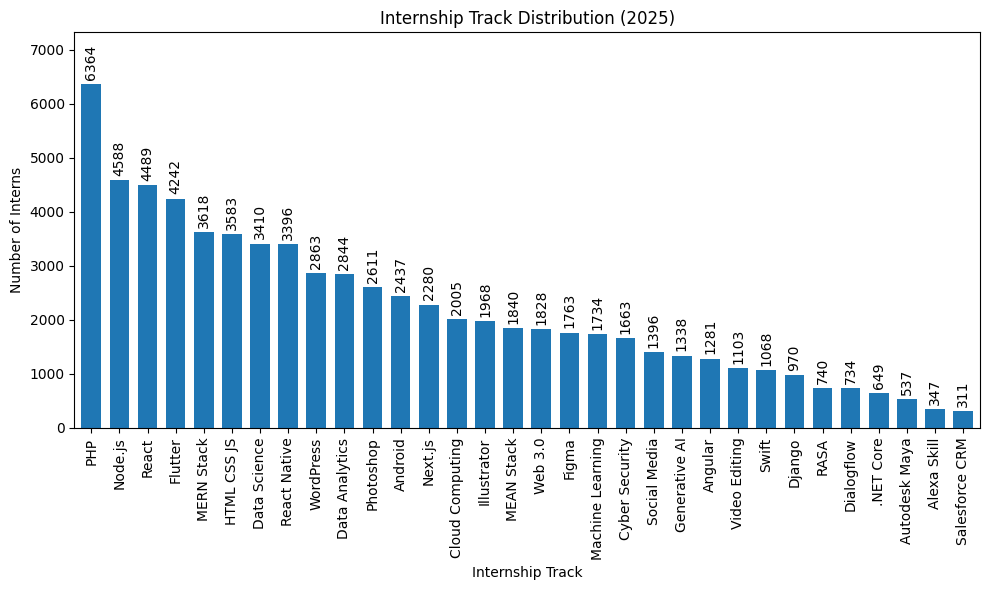

In [150]:
# Internship Track Distribution Visualization

# Create the bar chart
ax = track_distribution.plot(
    kind="bar",
    figsize=(10, 6),
    width=0.70
)

# Add chart title
plt.title("Internship Track Distribution (2025)")

# Add axis labels
plt.xlabel("Internship Track")
plt.ylabel("Number of Interns")

plt.ylim(0, track_distribution.max() * 1.15)

# Rotate x-axis labels
plt.xticks(rotation=90)

# Display data labels
for container in ax.containers:
    labels = ax.bar_label(
        container,
        padding=3
    )

    for label in labels:
        label.set_rotation(90)

# Adjust layout
plt.tight_layout()

# Save the figure
# plt.savefig(
#     "../outputs/figures/06_internship_track_distribution.png",
#     dpi=300,
#     bbox_inches="tight"
# )

# Display the chart
plt.show()

#### Observation

The internship track distribution reveals that **PHP** recorded the highest number of interns, followed by **Node.js**, **React**, and **Flutter**. Web development-related tracks collectively attracted the largest share of internship enrollments, indicating strong interest in full-stack and frontend technologies. In contrast, specialized tracks such as **Alexa Skill**, **Salesforce CRM**, **Autodesk Maya**, and **.NET Core** received comparatively lower enrollments, reflecting relatively limited participation.

#### Business Insight

The high demand for **PHP**, **Node.js**, **React**, and other web development technologies suggests that these tracks should remain a primary focus for mentor allocation, project availability, and training resources. At the same time, lower-enrollment tracks such as **Salesforce CRM**, **Alexa Skill**, and **Autodesk Maya** may benefit from targeted awareness campaigns, updated learning content, and industry-relevant projects to improve participation and diversify the internship portfolio.

### Monthly Internship Track Distribution

This graph presents the monthly distribution of internship enrollments across different internship tracks. It compares participation trends for each internship track across all enrollment months, helping identify seasonal enrollment patterns, peak participation periods, and changes in demand throughout the internship program.

In [158]:
# Monthly Internship Track Distribution

monthly_track_distribution = (
    internship_df
        .groupby(["Enrollment_Month", "Internship_Track"])
        .size()
        .unstack(fill_value=0)
        .reindex(month_order)
)

# Sort tracks by total enrollments (highest to lowest)
monthly_track_distribution = monthly_track_distribution[
    monthly_track_distribution.sum().sort_values(ascending=False).index
]

monthly_track_distribution.T

Enrollment_Month,January,February,March,April,May,June,July,August,September,October
Internship_Track,,,,,,,,,,
PHP,343,445,638,944,1143,1016,683,524,375,253
Node.js,220,326,451,709,819,741,470,349,311,192
React,219,339,425,656,817,716,495,369,292,161
Flutter,221,275,426,628,810,643,464,340,260,175
MERN Stack,174,254,370,541,636,557,418,284,204,180
HTML CSS JS,180,244,338,567,652,575,378,285,211,153
Data Science,196,246,333,490,648,551,351,254,206,135
React Native,194,271,339,491,602,535,373,258,210,123
WordPress,151,209,274,444,511,417,353,234,156,114


#### Monthly Internship Track Distribution Visualization

This heatmap illustrates the monthly distribution of internship enrollments across different internship tracks. Darker color intensity represents higher enrollment counts, making it easier to identify peak participation periods and compare enrollment trends across internship tracks throughout 2025.

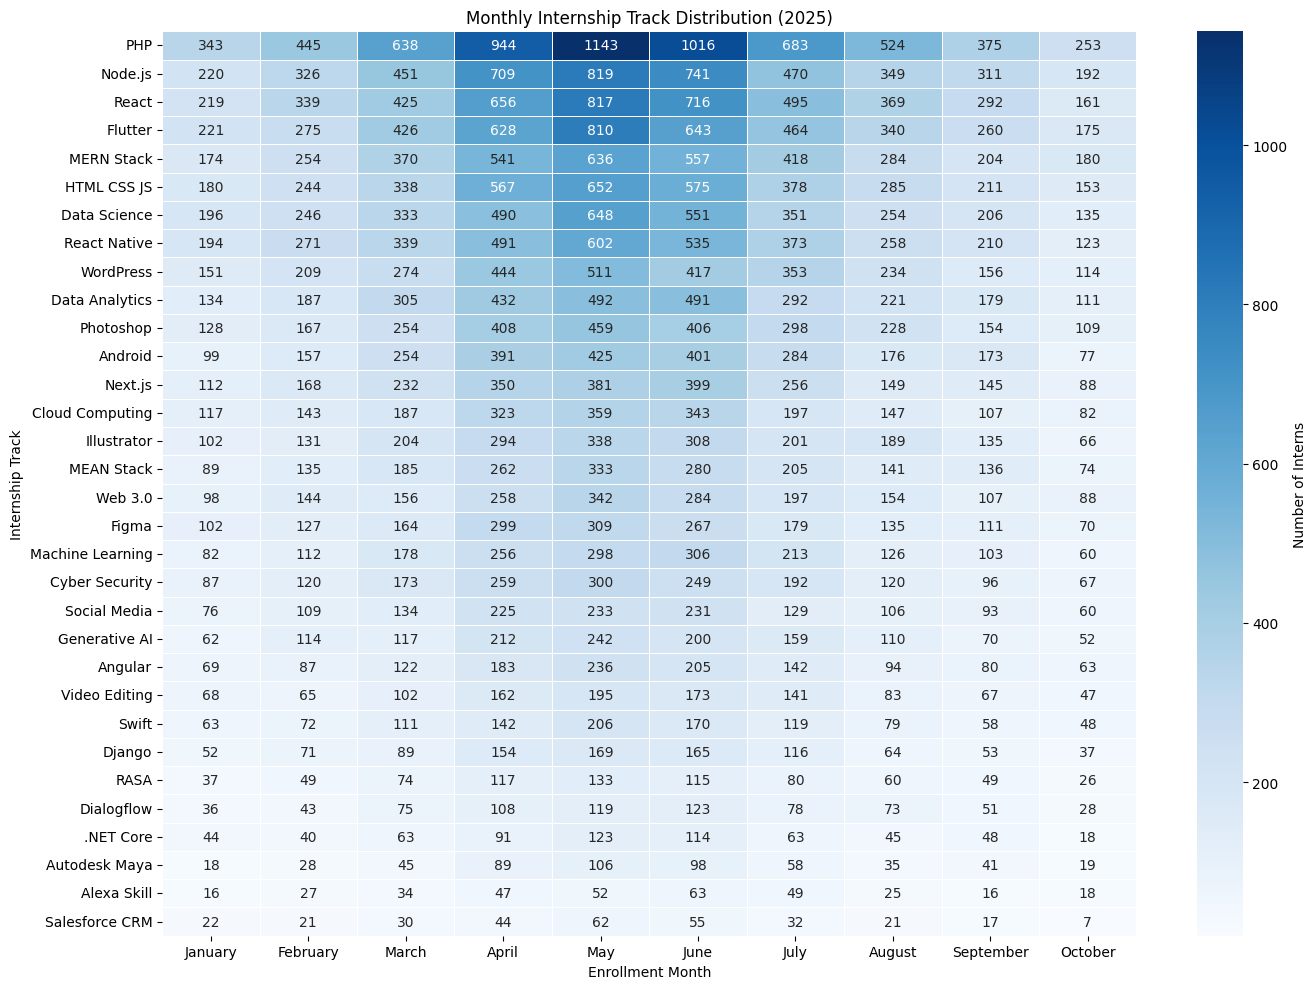

In [166]:
# Monthly Internship Track Distribution Visualization

# Create the heatmap
plt.figure(figsize=(14, 10))

sns.heatmap(
    monthly_track_distribution.T,
    annot=True,
    fmt="d",
    cmap="Blues",
    linewidths=0.5,
    cbar_kws={"label": "Number of Interns"}
)

# Add chart title
plt.title("Monthly Internship Track Distribution (2025)")

# Add axis labels
plt.xlabel("Enrollment Month")
plt.ylabel("Internship Track")

# Adjust layout
plt.tight_layout()

# Save the figure
# plt.savefig(
#     "../outputs/figures/07_monthly_internship_track_distribution.png",
#     dpi=300,
#     bbox_inches="tight"
# )

# Display the chart
plt.show()

#### Observation

The monthly internship track distribution heatmap shows that internship enrollments increased steadily from **January** and peaked during **May**, followed by a gradual decline through **October** across nearly all internship tracks. **PHP**, **Node.js**, **React**, and **Flutter** consistently recorded the highest enrollment counts throughout the internship period, while tracks such as **Salesforce CRM**, **Alexa Skill**, **Autodesk Maya**, and **.NET Core** maintained comparatively lower participation. Overall, the monthly enrollment pattern remained consistent across all internship tracks.

#### Business Insight

The consistently high demand for **PHP**, **Node.js**, **React**, and **Flutter** indicates that these internship tracks should continue to receive priority in mentor allocation, technical resources, and project opportunities, especially during the peak enrollment months of **April**, **May**, and **June**. Additionally, lower-enrollment tracks such as **Salesforce CRM**, **Alexa Skill**, and **Autodesk Maya** may benefit from targeted promotional campaigns, updated learning content, and industry-focused projects to increase participation and create a more balanced internship portfolio.

### Gender Distribution

This graph illustrates the distribution of interns by gender. It provides an overview of gender representation within the internship program, helping identify participation patterns and assess diversity across the enrolled interns.

In [169]:
# Gender Distribution

gender_distribution = (
    internship_df["Gender"]
    .value_counts()
)

gender_distribution

Gender
Female    35073
Male      34927
Name: count, dtype: int64

#### Gender Distribution Visualization

This bar chart illustrates the distribution of interns by gender. It compares the number of male and female interns, providing insights into gender representation within the internship program.

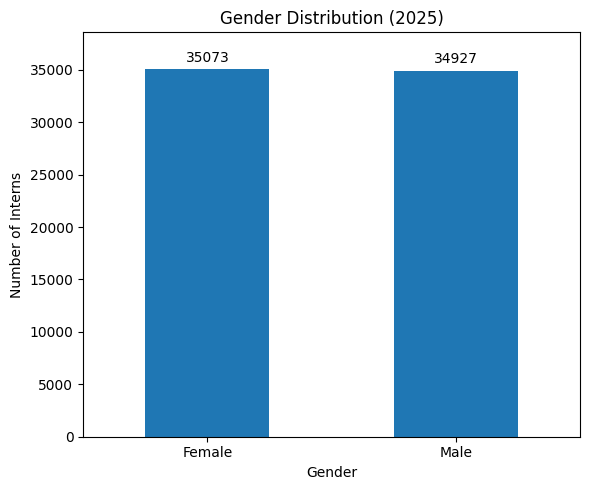

In [174]:
# Gender Distribution Visualization

# Create the bar chart
ax = gender_distribution.plot(
    kind="bar",
    figsize=(6, 5)
)

# Add chart title
plt.title("Gender Distribution (2025)")

# Add axis labels
plt.xlabel("Gender")
plt.ylabel("Number of Interns")

plt.ylim(0, gender_distribution.max() * 1.10)

# Rotate x-axis labels
plt.xticks(rotation=0)

# Display data labels
for container in ax.containers:
    ax.bar_label(
        container,
        padding=3
    )

# Adjust layout
plt.tight_layout()

# Save the figure
# plt.savefig(
#     "../outputs/figures/08_gender_distribution.png",
#     dpi=300,
#     bbox_inches="tight"
# )

# Display the chart
plt.show()

#### Observation

The gender distribution indicates a nearly balanced participation of interns, with **Female** interns (35,073) slightly outnumbering **Male** interns (34,927). The difference between the two groups is minimal, suggesting that the internship program maintained an almost equal level of gender representation throughout 2025.

#### Business Insight

The balanced gender distribution reflects an inclusive internship program that successfully attracts participants from both genders. Maintaining fair recruitment practices, equal learning opportunities, and unbiased mentor allocation can help sustain this balanced participation while promoting diversity and inclusion across future internship cohorts.

### Age Distribution

This graph illustrates the distribution of interns across different age groups. It provides insights into the age profile of participants, helping identify the most common age ranges within the internship program.

In [175]:
# Age Distribution

age_distribution = (
    internship_df["Age"]
    .value_counts()
    .sort_index()
)

age_distribution

Age
17    1432
18    1970
19    8695
20    8683
21    7405
22    7371
23    7847
24    7534
25    7618
26    7594
27     835
28     764
29     756
30     770
31     345
32     381
Name: count, dtype: int64

#### Age Distribution Visualization

This bar chart illustrates the distribution of interns across different ages. It compares the number of interns in each age group, providing insights into the overall age profile of participants in the internship program.

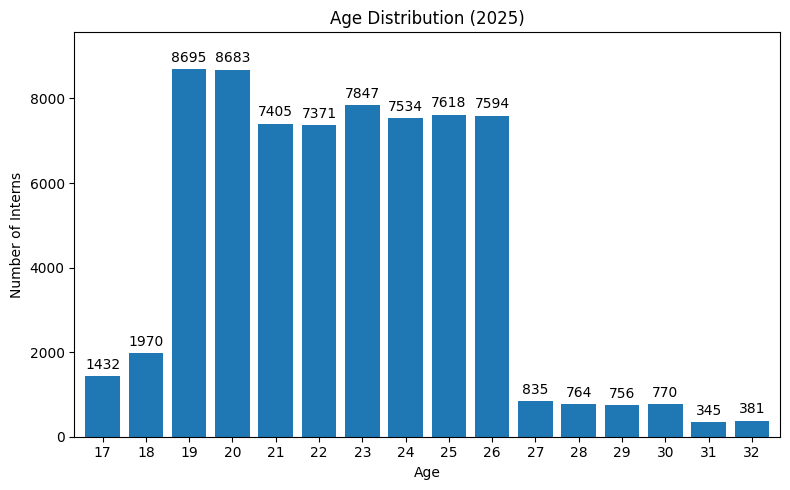

In [181]:
# Age Distribution Visualization

# Create the bar chart
ax = age_distribution.plot(
    kind="bar",
    figsize=(8, 5),
    width=0.80
)

# Add chart title
plt.title("Age Distribution (2025)")

# Add axis labels
plt.xlabel("Age")
plt.ylabel("Number of Interns")

plt.ylim(0, age_distribution.max() * 1.10)

# Rotate x-axis labels
plt.xticks(rotation=0)

# Display data labels
for container in ax.containers:
    ax.bar_label(
        container,
        padding=3,
    )

# Adjust layout
plt.tight_layout()

# Save the figure
# plt.savefig(
#     "../outputs/figures/09_age_distribution.png",
#     dpi=300,
#     bbox_inches="tight"
# )

# Display the chart
plt.show()

#### Observation

The age distribution shows that the majority of interns fall between **19 and 26 years** of age, with **19** and **20** years recording the highest number of enrollments. Participation declines noticeably for ages **17**, **18**, and **27–32**, indicating that relatively fewer interns belong to these age groups. Overall, the internship program primarily attracts young adults in the typical university-age range.

#### Business Insight

The concentration of interns between **19 and 26 years** suggests that the internship program primarily serves undergraduate and early-career students. Organizations should continue designing training content, mentorship programs, and project assignments that align with the learning needs of this age group. Additionally, targeted outreach initiatives for younger and older age groups may help broaden participation and create a more diverse internship community.

### Education Distribution

This Table illustrates the distribution of interns based on their educational qualification. It provides an overview of the academic backgrounds of participants, helping identify the education levels most represented in the internship program.

In [183]:
# Education Distribution

education_distribution = (
    internship_df["Education"]
    .value_counts()
)

education_distribution

Education
BS Computer Science                      10430
BS Information Technology                 9000
BS Software Engineering                   8342
BS Artificial Intelligence                6270
BS Data Science                           6183
BS Data Analytics                         5250
BS Cyber Security                         4147
BS Computer Engineering                   4092
MS Computer Science                       3095
MCS                                       2717
ICS                                       2663
DAE (Computer Information Technology)     2107
FSC (Pre-Engineering)                     2047
BBA                                       1027
DAE (Electrical Technology)                574
ICOM                                       543
MBA                                        509
FSC (Pre-Medical)                          506
DAE (Mechanical Technology)                498
Name: count, dtype: int64

#### Education Distribution Visualization

This bar chart illustrates the distribution of interns across different educational qualifications. It compares the number of interns in each education category, providing insights into the academic profile of participants in the internship program.

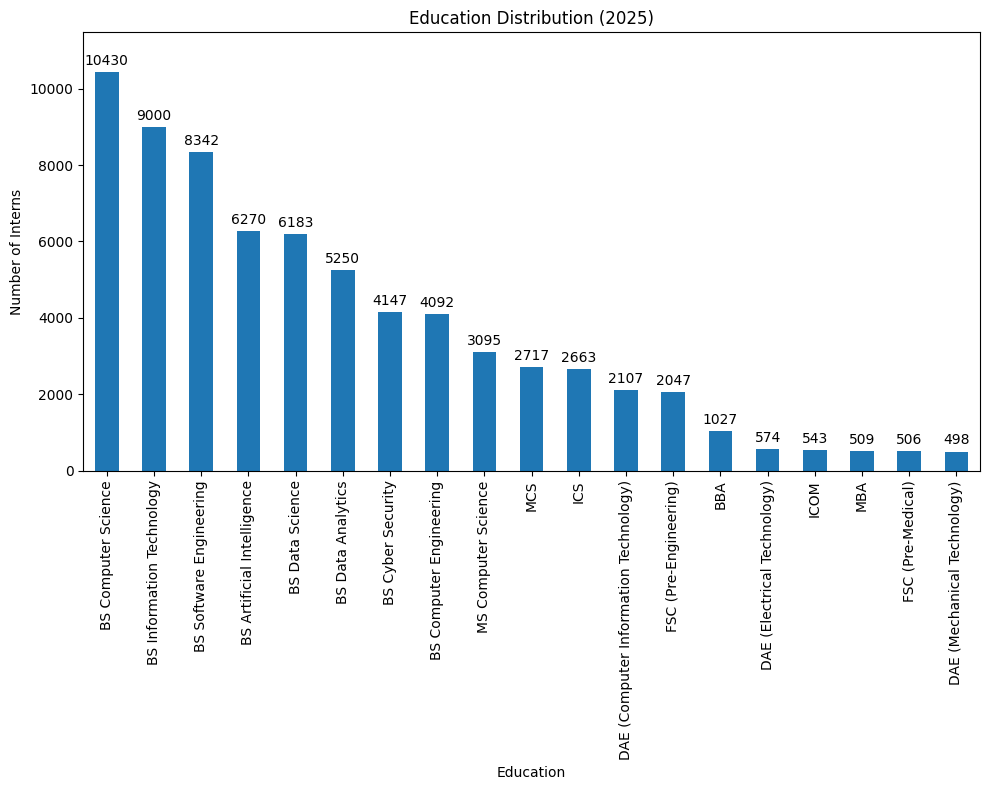

In [191]:
# Education Distribution Visualization

# Create the bar chart
ax = education_distribution.plot(
    kind="bar",
    figsize=(10, 8)
)

# Add chart title
plt.title("Education Distribution (2025)")

# Add axis labels
plt.xlabel("Education")
plt.ylabel("Number of Interns")

plt.ylim(0, education_distribution.max() * 1.10)

# Display data labels
for container in ax.containers:
    ax.bar_label(
        container,
        padding=3
    )

# Adjust layout
plt.tight_layout()

# Save the figure
# plt.savefig(
#     "../outputs/figures/10_education_distribution.png",
#     dpi=300,
#     bbox_inches="tight"
# )

# Display the chart
plt.show()

#### Observation

The education distribution indicates that **BS Computer Science** recorded the highest number of internship enrollments, followed by **BS Information Technology** and **BS Software Engineering**. Other computing-related disciplines, including **BS Artificial Intelligence**, **BS Data Science**, and **BS Data Analytics**, also contributed a substantial number of interns. In contrast, non-computing and diploma-level qualifications, such as **DAE**, **FSC**, **ICOM**, and **MBA**, accounted for comparatively lower participation.

#### Business Insight

The strong representation of **Computer Science**, **Information Technology**, and **Software Engineering** students indicates that the internship program primarily attracts participants from computing-related disciplines. Organizations should continue offering technical projects, mentorship, and learning opportunities tailored to these academic backgrounds. At the same time, targeted outreach and specialized internship pathways for students from non-computing disciplines may help broaden participation and promote a more diverse internship portfolio.